<a href="https://colab.research.google.com/github/Risqullah/Probstat_kelompok4-/blob/main/Analisis_Data_Kelompok_04_Terpisah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import Library & Data Cleaning

In [2]:
# ==========================================
# SECTION 1
# IMPORT LIBRARY & MEMBACA DATASET
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Membaca dataset Excel
df = pd.read_excel(
    '3TIA_04_DLSS5Study2.xlsx',
    sheet_name='Dataset_50_Rows'
)

print("=== DATASET AWAL ===")
print(f"Jumlah baris : {len(df)}")
print(f"Jumlah kolom : {len(df.columns)}")

print("\nNama variabel:")
print(df.columns.tolist())

=== DATASET AWAL ===
Jumlah baris : 51
Jumlah kolom : 6

Nama variabel:
['ID_Pengujian', 'Game_Title', 'Preset_DLSS', 'Performa_FPS', 'Skor_MOS', 'Visual_Artifacts']


# 2. Data Cleaning


In [3]:
# ==========================================
# SECTION 2
# DATA CLEANING
# ==========================================

# Menghapus baris yang bukan observasi
# Baris RATA-RATA tidak memiliki ID_Pengujian
df = df[df['ID_Pengujian'].notna()].copy()

# Memastikan data numerik
df['Performa_FPS'] = pd.to_numeric(
    df['Performa_FPS'],
    errors='coerce'
)

df['Skor_MOS'] = pd.to_numeric(
    df['Skor_MOS'],
    errors='coerce'
)

# Mengisi data kosong pada Visual_Artifacts
# 'None' digunakan untuk menunjukkan tidak terdapat artefak visual
df['Visual_Artifacts'] = df['Visual_Artifacts'].fillna('None')

print("=== HASIL CLEANING ===")
print(f"Jumlah observasi : {len(df)}")
print(f"Jumlah variabel  : {len(df.columns)}")

print("\nMissing Value:")
print(df.isnull().sum())

=== HASIL CLEANING ===
Jumlah observasi : 50
Jumlah variabel  : 6

Missing Value:
ID_Pengujian        0
Game_Title          0
Preset_DLSS         0
Performa_FPS        0
Skor_MOS            0
Visual_Artifacts    0
dtype: int64


# 3. Pemeriksaan Struktur Data


In [4]:
# ==========================================
# SECTION 3
# PEMERIKSAAN STRUKTUR DATA
# ==========================================

print("=== JUMLAH OBSERVASI PER KONDISI ===")

print(
    df['Preset_DLSS'].value_counts()
)

print("\n=== JUMLAH GAME ===")

print(
    df['Game_Title'].nunique()
)

print("\n=== DAFTAR GAME ===")

print(
    df['Game_Title'].unique()
)

print("\n=== JUMLAH ID PENGUJIAN ===")

print(
    df['ID_Pengujian'].nunique()
)

=== JUMLAH OBSERVASI PER KONDISI ===
Preset_DLSS
Native                    25
DLSS Cinematic Quality    25
Name: count, dtype: int64

=== JUMLAH GAME ===
5

=== DAFTAR GAME ===
['Downhill: Domination' 'Kingdom Hearts II' 'Gran Turismo 4'
 'Metal Gear Solid 3: Snake Eater' 'Shadow of the Colossus']

=== JUMLAH ID PENGUJIAN ===
25


# 4. Fungsi Modus


In [5]:
# ==========================================
# SECTION 4
# FUNGSI MODUS
# ==========================================

def get_mode(series):
    mode_values = series.mode()

    # Tidak ada modus jika semua nilai hanya muncul sekali
    if len(mode_values) == len(series):
        return "Tidak ada modus"

    return ", ".join(
        f"{value:.3f}" for value in mode_values
    )

#5. Statistika Deskriptif

In [6]:
# ==========================================
# SECTION 5
# STATISTIKA DESKRIPTIF
# ==========================================

import math

def descriptive_statistics(series):

    series = series.dropna()

    count = len(series)
    mean = series.mean()
    median = series.median()
    std = series.std()
    variance = series.var()
    standard_error = std / math.sqrt(count)

    q1 = series.quantile(0.25)
    q2 = series.quantile(0.50)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    minimum = series.min()
    maximum = series.max()
    data_range = maximum - minimum

    return {
        'Count': count,
        'Mean': mean,
        'Modus': get_mode(series),
        'Median / Q2': median,
        'Standard Error': standard_error,
        'Standar Deviasi': std,
        'Varians': variance,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'Minimum': minimum,
        'Maksimum': maximum,
        'Range': data_range
    }


# ------------------------------------------
# Statistik Performa FPS
# ------------------------------------------

print("=== STATISTIKA DESKRIPTIF PERFORMA FPS ===")

fps_stats = {}

for preset in [
    'Native',
    'DLSS Cinematic Quality'
]:

    data = df[
        df['Preset_DLSS'] == preset
    ]['Performa_FPS']

    fps_stats[preset] = descriptive_statistics(data)

fps_table = pd.DataFrame(fps_stats).T

print(
    fps_table.to_string()
)


# ------------------------------------------
# Statistik Skor MOS
# ------------------------------------------

print("\n=== STATISTIKA DESKRIPTIF SKOR MOS ===")

mos_stats = {}

for preset in [
    'Native',
    'DLSS Cinematic Quality'
]:

    data = df[
        df['Preset_DLSS'] == preset
    ]['Skor_MOS']

    mos_stats[preset] = descriptive_statistics(data)

mos_table = pd.DataFrame(mos_stats).T

print(
    mos_table.to_string()
)

=== STATISTIKA DESKRIPTIF PERFORMA FPS ===
                       Count    Mean                           Modus Median / Q2 Standard Error Standar Deviasi  Varians    Q1    Q3   IQR Minimum Maksimum Range
Native                    25  55.472  57.600, 57.700, 57.900, 58.800        56.7       0.645123        3.225616  10.4046  52.1  57.9   5.8    50.3     59.8   9.5
DLSS Cinematic Quality    25    46.2                 Tidak ada modus        48.7       1.579525        7.897626  62.3725  39.6  53.0  13.4    31.1     57.2  26.1

=== STATISTIKA DESKRIPTIF SKOR MOS ===
                       Count   Mean  Modus Median / Q2 Standard Error Standar Deviasi   Varians   Q1   Q3  IQR Minimum Maksimum Range
Native                    25  3.572  3.500         3.5       0.116264         0.58132  0.337933  3.2  3.7  0.5     2.6      4.8   2.2
DLSS Cinematic Quality    25  4.476  4.500         4.5       0.084119        0.420595    0.1769  4.2  4.8  0.6     3.6      5.0   1.4


#6. Statistik Tambahan

In [7]:
# ==========================================
# SECTION 6
# STATISTIK TAMBAHAN
# ==========================================

print("=== STATISTIK TAMBAHAN PERFORMA FPS ===")

for preset in [
    'Native',
    'DLSS Cinematic Quality'
]:

    data = df[
        df['Preset_DLSS'] == preset
    ]['Performa_FPS']

    mean = data.mean()
    std = data.std()

    cv = (std / mean) * 100
    skewness = data.skew()
    kurtosis = data.kurt()

    print(f"\n{preset}")
    print(f"Coefficient of Variation : {cv:.3f}%")
    print(f"Skewness                  : {skewness:.3f}")
    print(f"Kurtosis                  : {kurtosis:.3f}")

=== STATISTIK TAMBAHAN PERFORMA FPS ===

Native
Coefficient of Variation : 5.815%
Skewness                  : -0.408
Kurtosis                  : -1.477

DLSS Cinematic Quality
Coefficient of Variation : 17.094%
Skewness                  : -0.303
Kurtosis                  : -1.173


#7. Rata-rata Statistik per Game

In [8]:
# ==========================================
# SECTION 7
# STATISTIKA DESKRIPTIF PER JUDUL GAME
# ==========================================

print("\n=== STATISTIKA DESKRIPTIF PER JUDUL GAME ===")

game_stats = df.groupby(
    ['Game_Title', 'Preset_DLSS']
)[
    ['Performa_FPS', 'Skor_MOS']
].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

print(
    game_stats.to_string()
)


=== STATISTIKA DESKRIPTIF PER JUDUL GAME ===
                                                       Performa_FPS                                     Skor_MOS                                 
                                                              count   mean median       std   min   max    count  mean median       std  min  max
Game_Title                      Preset_DLSS                                                                                                      
Downhill: Domination            DLSS Cinematic Quality            5  47.52   48.7  2.965131  44.2  50.5        5  4.58    4.5  0.370135  4.1  5.0
                                Native                            5  57.74   57.7  1.064425  56.2  59.2        5  3.36    3.3  0.240832  3.1  3.7
Gran Turismo 4                  DLSS Cinematic Quality            5  51.86   51.0  2.068333  49.8  54.9        5  4.66    4.6  0.181659  4.5  4.9
                                Native                            5  57.42   5

#8. Konfigurasi Visualisasi

In [9]:
# ==========================================
# SECTION 8
# KONFIGURASI VISUALISASI
# ==========================================

sns.set_theme(
    style="whitegrid",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False
    }
)

#9. Boxplot FPS dan MOS

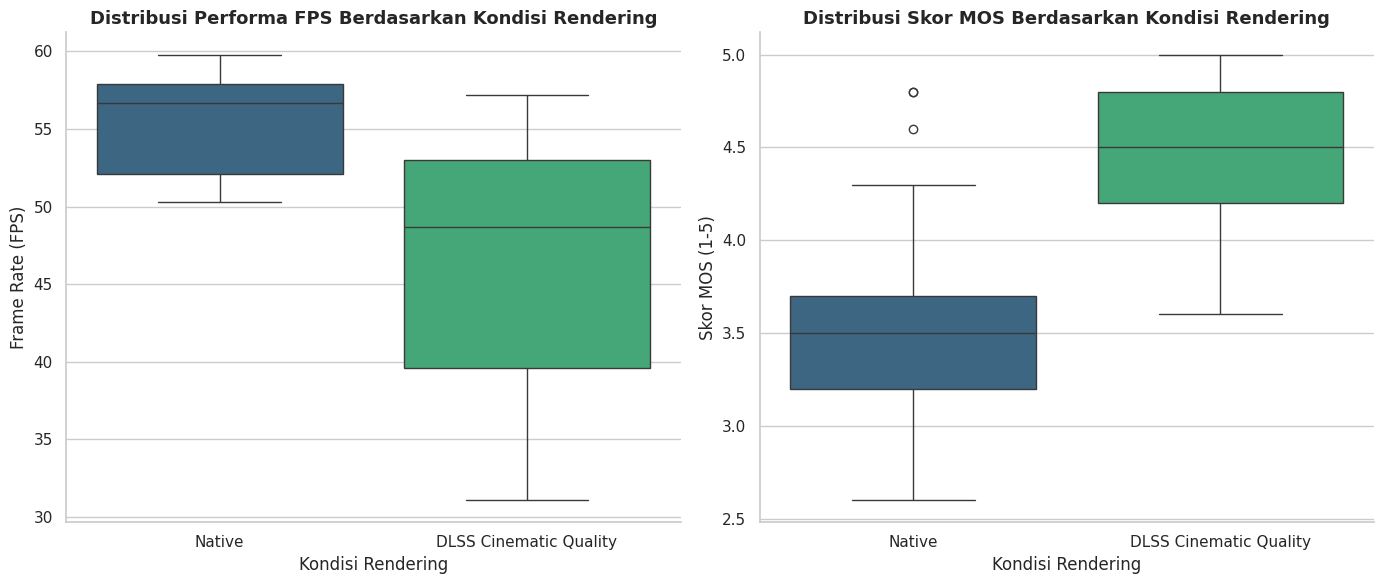

In [10]:
# ==========================================
# SECTION 9
# BOXPLOT FPS DAN MOS
# ==========================================

plt.figure(figsize=(14, 6))

# ------------------------------------------
# Boxplot FPS
# ------------------------------------------

plt.subplot(1, 2, 1)

sns.boxplot(
    data=df,
    x='Preset_DLSS',
    y='Performa_FPS',
    hue='Preset_DLSS',
    legend=False,
    palette='viridis'
)

plt.title(
    'Distribusi Performa FPS Berdasarkan Kondisi Rendering',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Kondisi Rendering')
plt.ylabel('Frame Rate (FPS)')


# ------------------------------------------
# Boxplot MOS
# ------------------------------------------

plt.subplot(1, 2, 2)

sns.boxplot(
    data=df,
    x='Preset_DLSS',
    y='Skor_MOS',
    hue='Preset_DLSS',
    legend=False,
    palette='viridis'
)

plt.title(
    'Distribusi Skor MOS Berdasarkan Kondisi Rendering',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Kondisi Rendering')
plt.ylabel('Skor MOS (1-5)')

plt.tight_layout()
plt.show()

#10. Bar Chart Rata-rata FPS per Game

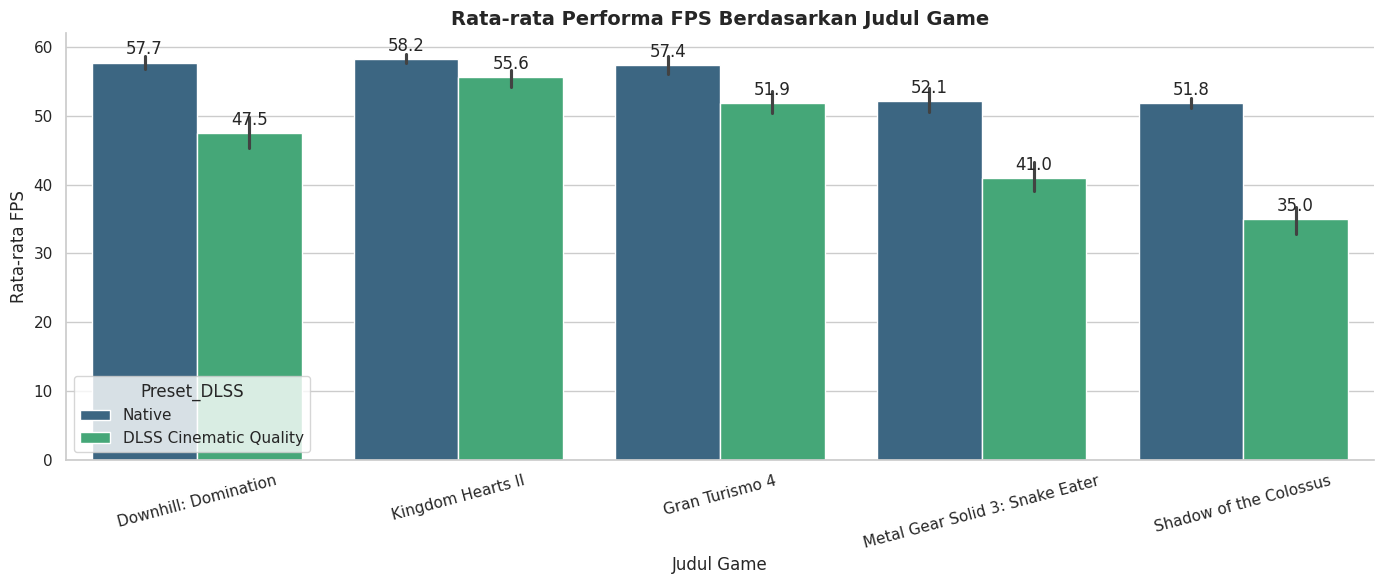

In [11]:
# ==========================================
# SECTION 10
# RATA-RATA FPS PER GAME
# ==========================================

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=df,
    x='Game_Title',
    y='Performa_FPS',
    hue='Preset_DLSS',
    palette='viridis'
)

plt.title(
    'Rata-rata Performa FPS Berdasarkan Judul Game',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Judul Game')
plt.ylabel('Rata-rata FPS')

plt.xticks(rotation=15)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f',
        padding=3
    )

plt.tight_layout()
plt.show()

#11. Bar Chart Rata-rata MOS per Game

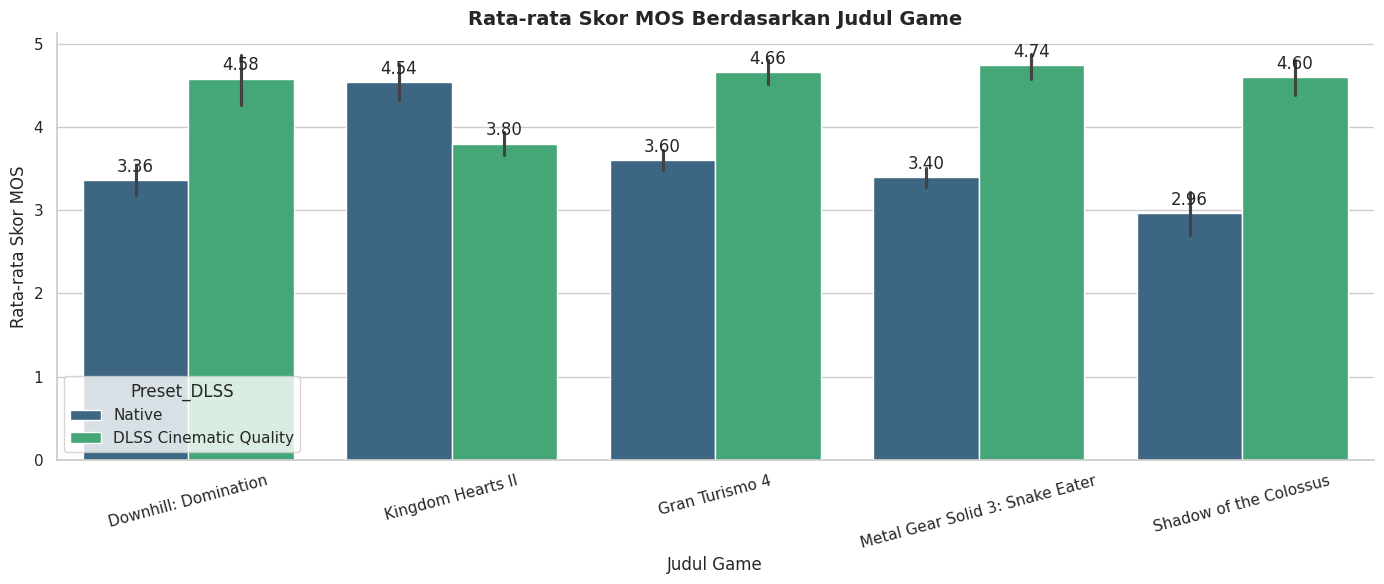

In [12]:
# ==========================================
# SECTION 11
# RATA-RATA MOS PER GAME
# ==========================================

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=df,
    x='Game_Title',
    y='Skor_MOS',
    hue='Preset_DLSS',
    palette='viridis'
)

plt.title(
    'Rata-rata Skor MOS Berdasarkan Judul Game',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Judul Game')
plt.ylabel('Rata-rata Skor MOS')

plt.xticks(rotation=15)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3
    )

plt.tight_layout()
plt.show()

#12. Probabilitas Empiris

In [13]:
# ==========================================
# SECTION 12
# PROBABILITAS EMPIRIS
# ==========================================

print("\n=== PROBABILITAS EMPIRIS FPS > 50 ===")

# Keseluruhan data
total_observasi = len(df)

jumlah_fps_diatas_50 = (
    df['Performa_FPS'] > 50
).sum()

probabilitas_total = (
    jumlah_fps_diatas_50 /
    total_observasi
)

print(
    f"Keseluruhan : "
    f"{jumlah_fps_diatas_50}/{total_observasi} "
    f"= {probabilitas_total:.2f} "
    f"atau {probabilitas_total * 100:.0f}%"
)


# Native
native_data = df[
    df['Preset_DLSS'] == 'Native'
]

native_diatas_50 = (
    native_data['Performa_FPS'] > 50
).sum()

probabilitas_native = (
    native_diatas_50 /
    len(native_data)
)

print(
    f"Native      : "
    f"{native_diatas_50}/{len(native_data)} "
    f"= {probabilitas_native:.2f} "
    f"atau {probabilitas_native * 100:.0f}%"
)


# DLSS
dlss_data = df[
    df['Preset_DLSS'] == 'DLSS Cinematic Quality'
]

dlss_diatas_50 = (
    dlss_data['Performa_FPS'] > 50
).sum()

probabilitas_dlss = (
    dlss_diatas_50 /
    len(dlss_data)
)

print(
    f"DLSS        : "
    f"{dlss_diatas_50}/{len(dlss_data)} "
    f"= {probabilitas_dlss:.2f} "
    f"atau {probabilitas_dlss * 100:.0f}%"
)


=== PROBABILITAS EMPIRIS FPS > 50 ===
Keseluruhan : 35/50 = 0.70 atau 70%
Native      : 25/25 = 1.00 atau 100%
DLSS        : 10/25 = 0.40 atau 40%


#13. Ringkasan Hasil Utama

In [14]:
# ==========================================
# SECTION 13
# RINGKASAN HASIL UTAMA
# ==========================================

print("\n=== RINGKASAN HASIL PENELITIAN ===")

print(
    f"Mean FPS Native       : "
    f"{df[df['Preset_DLSS'] == 'Native']['Performa_FPS'].mean():.3f}"
)

print(
    f"Mean FPS DLSS         : "
    f"{df[df['Preset_DLSS'] == 'DLSS Cinematic Quality']['Performa_FPS'].mean():.3f}"
)

print(
    f"Mean MOS Native       : "
    f"{df[df['Preset_DLSS'] == 'Native']['Skor_MOS'].mean():.3f}"
)

print(
    f"Mean MOS DLSS         : "
    f"{df[df['Preset_DLSS'] == 'DLSS Cinematic Quality']['Skor_MOS'].mean():.3f}"
)

print(
    f"Probabilitas FPS > 50 : "
    f"{probabilitas_total * 100:.0f}%"
)


=== RINGKASAN HASIL PENELITIAN ===
Mean FPS Native       : 55.472
Mean FPS DLSS         : 46.200
Mean MOS Native       : 3.572
Mean MOS DLSS         : 4.476
Probabilitas FPS > 50 : 70%
